In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tkinter.messagebox import IGNORE
from statsmodels.tsa.stattools import adfuller

# PREPROCESAMIENTO

In [ ]:
# # EXTRACION DE DATA CRUDA DE EXCEL
df = pd.read_excel("/content/drive/MyDrive/MAESTRIA/skbo_metar.xlsx")

In [ ]:
df_raw = df.copy()

# Eliminar registros inválidos que contienen "NIL"
registros_iniciales = len(df_raw)
invalid_count = df_raw["TEXTO_REPORTE"].str.contains("NIL", na=False).sum()
invalid_percent = (invalid_count / registros_iniciales) * 100

print(f"\n Registros iniciales: {registros_iniciales:,}")
print(f" Registros inválidos (NIL): {invalid_count:,} ({invalid_percent:.2f}%)")

# Eliminar registros inválidos
df_raw = df_raw[~df_raw["TEXTO_REPORTE"].str.contains("NIL", na=False)].copy()

registros_validos = len(df_raw)
print(f" Registros válidos después de limpieza: {registros_validos:,}")
print(f" Registros eliminados: {registros_iniciales - registros_validos:,}")

# Verificar forma después de limpieza
print(f"\n Forma del dataset después de limpieza: {df_raw.shape}")

# Crear columna unificada de fecha y hora
# Las columnas FECHA_REPORTE y HORA_REPORTE contienen información redundante
# Unificamos en una sola columna datetime para facilitar el análisis temporal

print("=" * 60)
print("NORMALIZACIÓN DE FECHAS")
print("=" * 60)

df_raw["FECHA_HORA_REPORTE"] = pd.to_datetime(df_raw["FECHA_REPORTE"].astype(str), errors='coerce')

# Verificar conversión
fechas_invalidas = df_raw["FECHA_HORA_REPORTE"].isna().sum()
if fechas_invalidas > 0:
    print(f"  Advertencia: {fechas_invalidas} fechas no pudieron ser convertidas")

print(f" Columna FECHA_HORA_REPORTE creada")
print(f"   Rango: {df_raw['FECHA_HORA_REPORTE'].min()} a {df_raw['FECHA_HORA_REPORTE'].max()}")

# Extraer componentes temporales para uso posterior
df_raw["Año"] = df_raw["FECHA_HORA_REPORTE"].dt.year
df_raw["Mes"] = df_raw["FECHA_HORA_REPORTE"].dt.month
df_raw["Dia"] = df_raw["FECHA_HORA_REPORTE"].dt.day
df_raw["Hora"] = df_raw["FECHA_HORA_REPORTE"].dt.hour

# Eliminar registro con fecha 1900 si existe (error de datos)
if df_raw[df_raw['Año'] == 1900].shape[0] > 0:
    registros_eliminados_fecha = len(df_raw[df_raw['Año'] == 1900])
    df_raw = df_raw[df_raw['Año'] != 1900].copy()
    print(f" Eliminados {registros_eliminados_fecha} registros con fecha inválida (1900)")

print(f"\n Forma del dataset después de normalización: {df_raw.shape}")

# Verificar valores nulos en el dataframe completo y mostrar resumen
print("=" * 60)
print("VERIFICACIÓN DE VALORES NULOS")
print("=" * 60)
nulos_por_columna = df_raw.isnull().sum()
print(nulos_por_columna[nulos_por_columna > 0])

total_nulos = df_raw.isnull().sum().sum()
#print(f"Total de valores nulos en el dataframe: {total_nulos}")

# Si se quiere enfocar en columnas clave:
columnas_clave = ["FECHA_REPORTE", "TEXTO_REPORTE"]
for col in columnas_clave:
    if col in df_raw.columns:
        nulos = df_raw[col].isnull().sum()
        print(f"{col}: {nulos} nulos")

# 1. Definir el patrón Regex
# \bAUTO\b busca la palabra exacta "AUTO"
# \s? busca un espacio opcional después de la palabra
patron_auto = r'\bAUTO\b\s?'

# 2. Aplicar la limpieza en la columna original
# Usamos regex=True para que interprete el patrón correctamente
df_raw["TEXTO_REPORTE_CLEAN"] = (
    df_raw["TEXTO_REPORTE"]
    .str.replace(patron_auto, "", regex=True, flags=re.IGNORECASE)
    .str.strip() # Elimina espacios al inicio o final si los hubiera
)

# 3. Tokenizar el texto ya limpio
df_raw["tokens"] = df_raw["TEXTO_REPORTE_CLEAN"].str.split()

print(f" Texto tokenizado")
print(f"   Ejemplo de tokens: {df_raw['tokens'].iloc[0][:5]}...")  # Mostrar primeros 5 tokens

df_raw[['TEXTO_REPORTE', 'tokens']].head(3)

# Borrar las filas donde el df_raw["tokens"].str[0] tenga una longitud diferente de 4 osea que el aerodromo fue mal diligenciado
print(f"Forma del DataFrame antes de la limpieza AERODROMO: {df_raw.shape}")

df_raw = df_raw[df_raw['tokens'].str[0].str.len() == 4].copy()

print(f"Forma del DataFrame después de la limpieza AERODROMO: {df_raw.shape}")

# Borrar las filas donde el df_raw["tokens"].str[1] tenga una longitud de 6 y 7 osea que la hora esta completa y tambien que le falto la Z al final
print(f"Forma del DataFrame antes de la limpieza HORA: {df_raw.shape}")

df_raw = df_raw[(df_raw['tokens'].str[1].str.len() == 6) | (df_raw['tokens'].str[1].str.len() == 7)].copy()

print(f"Forma del DataFrame después de la limpieza HORA: {df_raw.shape}")

# Borrar las filas donde el df_raw["tokens"].str[2] tenga una longitud diferente del 6 al 10 osea que la hora esta completa y tambien que le falto la Z al final
print(f"Forma del DataFrame antes de la limpieza VIENTO: {df_raw.shape}")

df_raw = df_raw[df_raw['tokens'].str[2].str.len().isin([6,7,8,9,10])].copy()

print(f"Forma del DataFrame después de la limpieza VIENTO: {df_raw.shape}")

# Paso 2: Extracción de variables meteorológicas usando parsing estructurado
# Los reportes METAR siguen un formato estándar: AERODROMO FECHAZ VIENTO VISIBILIDAD TEMP/ROCIO PRESION NUBOSIDAD FENOMENOS

print("Extrayendo variables meteorológicas...")

# Variables básicas (por posición en el tokenizado)
df_raw["aerodromo"] = df_raw["tokens"].str[0]      # Primer token: código del aeródromo
df_raw["fecha_zulu"] = df_raw["tokens"].str[1]     # Segundo token: fecha Zulu
df_raw["viento"] = df_raw["tokens"].str[2]         # Tercer token: viento


df_preprocesado = df_raw[["FECHA_REPORTE",'Año', 'Mes', 'Dia', 'Hora','viento']]
print(df_preprocesado.head())

# Exportar el dataset procesado a un archivo CSV
# Este archivo será utilizado en las siguientes etapas del proyecto:
# - Feature engineering
# - Análisis exploratorio avanzado
# - Modelado y predicción

print("=" * 70)
print("EXPORTACIÓN DEL DATASET PROCESADO")
print("=" * 70)
# "/content/drive/MyDrive/MAESTRIA/
ruta_exportacion = '/content/drive/MyDrive/MAESTRIA/DATOS_PROCESADOS.csv'

# Verificar que el directorio existe (crearlo si no existe)
import os
directorio = os.path.dirname(ruta_exportacion)
if not os.path.exists(directorio):
    os.makedirs(directorio, exist_ok=True)
    print(f" Directorio creado: {directorio}")

# Exportar a CSV
df_preprocesado.to_csv(ruta_exportacion, index=False)

print(f"\n Dataset exportado exitosamente")
print(f"   Ruta: {ruta_exportacion}")
print(f"   Forma: {df_preprocesado.shape[0]:,} registros x {df_preprocesado.shape[1]} columnas")
print(f"   Tamaño del archivo: {os.path.getsize(ruta_exportacion) / 1024**2:.2f} MB")

# Verificar exportación
df_verificacion = pd.read_csv(ruta_exportacion)
print(f"\n Verificación de exportación:")
print(f"   Registros exportados: {len(df_verificacion):,}")
print(f"   Columnas exportadas: {len(df_verificacion.columns)}")
print(f"   Coincide con original: {len(df_verificacion) == len(df_preprocesado)}")



 Registros iniciales: 171,947
 Registros inválidos (NIL): 2,043 (1.19%)
 Registros válidos después de limpieza: 169,904
 Registros eliminados: 2,043

 Forma del dataset después de limpieza: (169904, 9)
NORMALIZACIÓN DE FECHAS
 Columna FECHA_HORA_REPORTE creada
   Rango: 2006-07-20 00:00:00 a 2026-04-09 18:00:00

 Forma del dataset después de normalización: (169904, 14)
VERIFICACIÓN DE VALORES NULOS
FECHA_INGRESO            18364
CEDULA                  166206
FECHA_HORA_INSERCION     29988
dtype: int64
FECHA_REPORTE: 0 nulos
TEXTO_REPORTE: 0 nulos
 Texto tokenizado
   Ejemplo de tokens: ['SKBO', '200000Z', '03004KT', '9999', 'SCT017']...
Forma del DataFrame antes de la limpieza AERODROMO: (169904, 16)
Forma del DataFrame después de la limpieza AERODROMO: (169875, 16)
Forma del DataFrame antes de la limpieza HORA: (169875, 16)
Forma del DataFrame después de la limpieza HORA: (169866, 16)
Forma del DataFrame antes de la limpieza VIENTO: (169866, 16)
Forma del DataFrame después de la lim

In [ ]:
df_preprocesado[df_preprocesado['FECHA_REPORTE'] == '2021-12-13 01:00:00.000']

,FECHA_REPORTE,Año,Mes,Dia,Hora,viento
129827,2021-12-13 01:00:00.000,2021,12,13,1,2905KT


# VERIFICACION DATOS FALTANTES

In [ ]:
# EXTRACION DE DATA PREPROCESADA
df_datos_preprocesados = pd.read_csv('/content/drive/MyDrive/MAESTRIA/DATOS_PROCESADOS.csv')

In [ ]:
df_pre_copy = df_datos_preprocesados.copy()

In [ ]:
df_pre_copy.head()

,FECHA_REPORTE,Año,Mes,Dia,Hora,viento
0,2006-07-20 00:00:00.000,2006,7,20,0,03004KT
1,2006-07-20 01:00:00.000,2006,7,20,1,29004KT
2,2006-07-20 05:00:00.000,2006,7,20,5,VRB02KT
3,2006-07-20 06:00:00.000,2006,7,20,6,VRB02KT
4,2006-07-20 07:00:00.000,2006,7,20,7,VRB02KT


In [ ]:
# Convertir FECHA_HORA_REPORTE a datetime y establecer como índice
df_pre_copy['FECHA_REPORTE'] = pd.to_datetime(df_pre_copy['FECHA_REPORTE'])
df_pre_copy.set_index('FECHA_REPORTE', inplace=True)

# Eliminación de variables no necesarias, solo me quedo con la columna de viento
df_pre_copy.drop(columns=['Año', 'Mes', 'Dia', 'Hora'], inplace=True)

# Eliminar valores nulos en la columna 'viento' antes de aplicar el parseo
df_pre_copy = df_pre_copy[df_pre_copy['viento'].notna()]

# Modificar el valor KKT, T, K  por KT en la columna de viento
df_pre_copy['viento'] = df_pre_copy['viento'].str.replace(r'[A-Za-z]{3}$', 'KT', regex=True)

def parse_viento_flexible(cadena):
    if pd.isna(cadena) or not isinstance(cadena, str):
        return pd.Series([None, None, None])

    patron = r'^(\d{3}|VRB)(\d{2,3})(G\d{2,3})?KT$'
    match = re.match(patron, cadena)

    if match:
        dir_raw = match.group(1)
        vel_raw = match.group(2)
        gus_raw = match.group(3)

        direccion = float(dir_raw) if dir_raw != 'VRB' else None
        velocidad = float(vel_raw)

        # CORRECCIÓN: Si no hay ráfaga (gus_raw es None), ponemos 0
        rafaga = float(gus_raw[1:]) if gus_raw else 0.0

        return pd.Series([direccion, velocidad, rafaga])

    return pd.Series([None, None, None])

# Aplicación Regex para parsear la columna de viento con formato flexible
df_pre_copy[['direccion', 'intensidad_kt', 'rafaga_kt']] = df_pre_copy['viento'].apply(parse_viento_flexible)

# Toma el último grado válido (ej. 030) y lo pone donde estaba el NaN de 'VRB'
df_pre_copy['direccion'] = df_pre_copy['direccion'].ffill()

# Elimino errores de digitación, por lo cual me quedo cuando la longitud de viento es mayor a 7
df_pre_copy = df_pre_copy[df_pre_copy['viento'].str.len() > 6]

# Elimino aquellos que no se identifica intensidad del viento
df_pre_copy = df_pre_copy[df_pre_copy["intensidad_kt"].notnull()]

# Verificar cuantos no tienen la estructura
df_pre_copy["viento"].str.len().value_counts()

# Eliminar valores donde la dirección es muy desfazada
df_pre_copy = df_pre_copy[df_pre_copy["direccion"] <= 360]


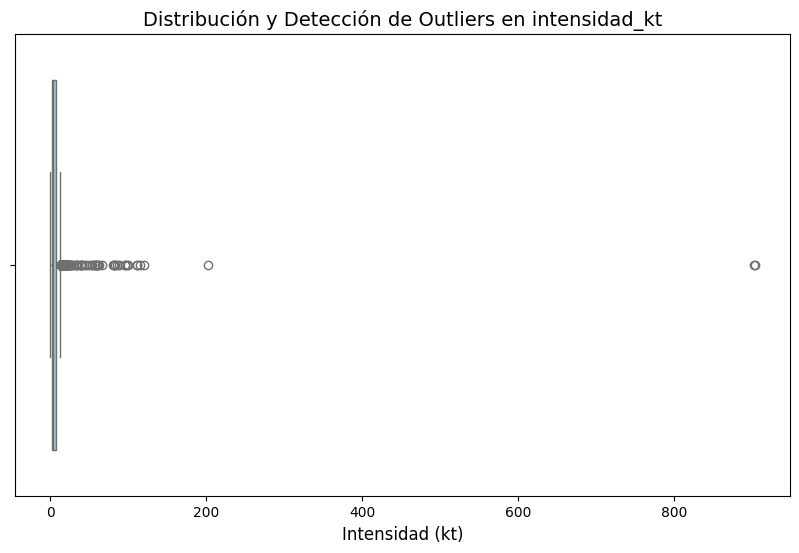

In [ ]:
# Verificación outliers

# Configurar el tamaño de la figura (opcional, pero recomendado)
plt.figure(figsize=(10, 6))

# Crear el boxplot de la columna "intensidad_kt"
# Usamos orient='h' para que sea horizontal, suele facilitar la lectura de la dispersión
sns.boxplot(x=df_pre_copy["intensidad_kt"], color='skyblue')

# Añadir título y etiquetas
plt.title('Distribución y Detección de Outliers en intensidad_kt', fontsize=14)
plt.xlabel('Intensidad (kt)', fontsize=12)

# Mostrar el gráfico
plt.show()

# Noticia de vientos de bogota https://portal.gestiondelriesgo.gov.co/paginas/old_noticias/225.aspx
# https://portal.gestiondelriesgo.gov.co/paginas/old_noticias/225.aspx

# umbral para la sabana de Bogotá
umbral_maximo = 40

# Todo valor mayor al umbral se vuelve nulo ANTES de cualquier cálculo
df_pre_copy.loc[df_pre_copy['intensidad_kt'] > umbral_maximo, 'intensidad_kt'] = np.nan

### Datos faltantes

In [ ]:
# 1. Crear el horario maestro (ejemplo: cada 1 hora)
rango_teorico = pd.date_range(start=df_pre_copy.index.min().floor('H'),
                              end=df_pre_copy.index.max().ceil('H'),
                              freq='1H')

# 2. Identificar qué horas del maestro no están en tus datos
horas_faltantes = rango_teorico.difference(df_pre_copy.index)
print(f"Total de reportes faltantes: {len(horas_faltantes)}")

# Identificar reportes que no ocurren exactamente en la hora (minuto != 0)
reportes_especiales = df_pre_copy[df_pre_copy.index.minute != 0]
print(f"Reportes extra encontrados: {len(reportes_especiales)}")

Total de reportes faltantes: 13337
Reportes extra encontrados: 9782


/tmp/ipykernel_13746/1832988519.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rango_teorico = pd.date_range(start=df_pre_copy.index.min().floor('H'),
/tmp/ipykernel_13746/1832988519.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end=df_pre_copy.index.max().ceil('H'),


#### Descomposicion de dirección e intensidad del viento

In [ ]:
# =========================================================
# FASE 1: PREPARACIÓN DEL ÍNDICE Y CÁLCULO DE COMPONENTES
# =========================================================

# Asegurarnos de que el índice de dataset original es formato datetime
df_pre_copy.index = pd.to_datetime(df_pre_copy.index)

# PASO CRÍTICO: Redondear los reportes a la hora en punto más cercana.
# Esto sincroniza reportes emitidos al minuto 50-59 con la hora exacta.
df_pre_copy.index = df_pre_copy.index.round('H')

# Al redondear, un reporte regular y un reporte especial (SPECI) podrían caer
# en la misma hora. Conservamos el último (el más actualizado).
df_pre_copy = df_pre_copy[~df_pre_copy.index.duplicated(keep='last')]

# Calcular u y v desde cero:
df_pre_copy['u'] = -df_pre_copy['intensidad_kt'] * np.sin(np.radians(df_pre_copy['direccion']))
df_pre_copy['v'] = -df_pre_copy['intensidad_kt'] * np.cos(np.radians(df_pre_copy['direccion']))

/tmp/ipykernel_13746/564785493.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_pre_copy.index = df_pre_copy.index.round('H')


In [ ]:
df_pre_copy.head()

,viento,direccion,intensidad_kt,rafaga_kt,u,v
FECHA_REPORTE,,,,,,
2006-07-20 00:00:00,03004KT,30.0,4.0,0.0,-2.000000,-3.464102
2006-07-20 01:00:00,29004KT,290.0,4.0,0.0,3.758770,-1.368081
2006-07-20 05:00:00,VRB02KT,290.0,2.0,0.0,1.879385,-0.684040
2006-07-20 06:00:00,VRB02KT,290.0,2.0,0.0,1.879385,-0.684040
2006-07-20 07:00:00,VRB02KT,290.0,2.0,0.0,1.879385,-0.684040


/tmp/ipykernel_13746/4099261218.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rango_completo = pd.date_range(start='2006-01-01', end='2026-12-31 23:00:00', freq='H')


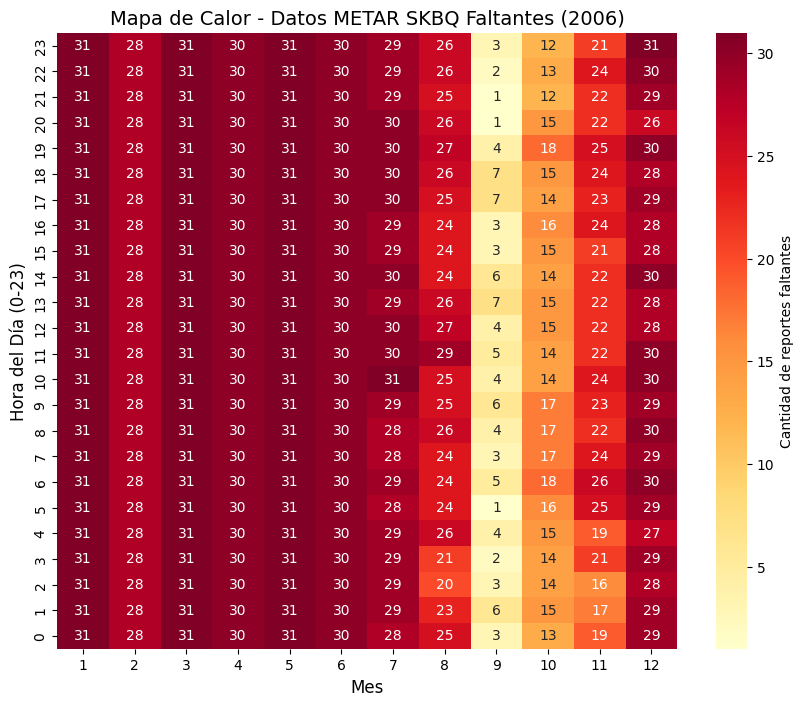

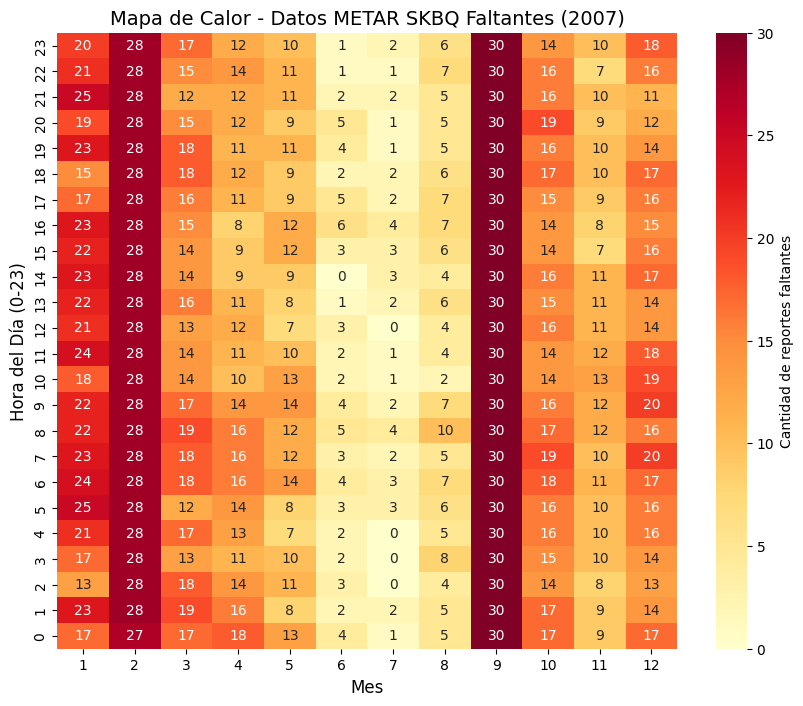

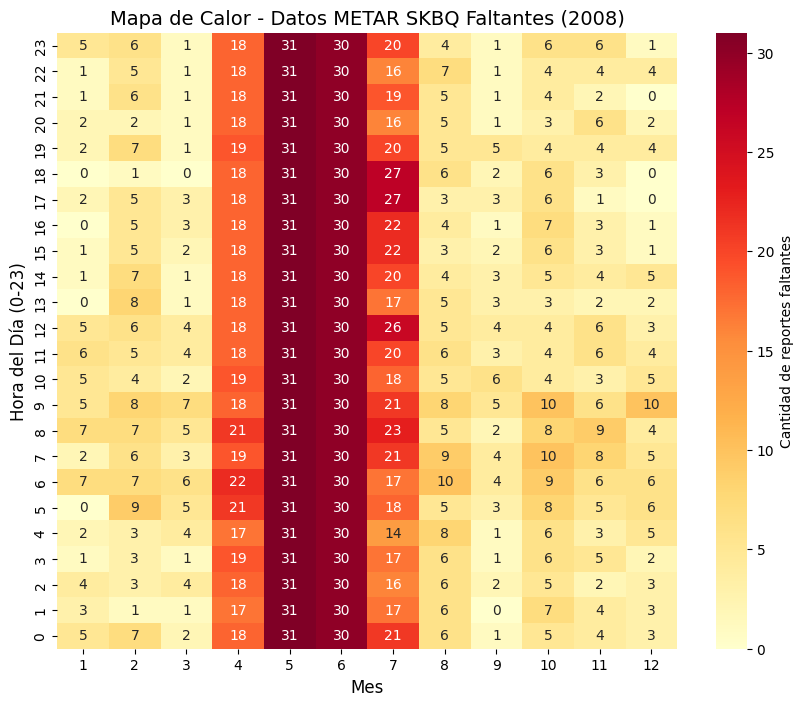

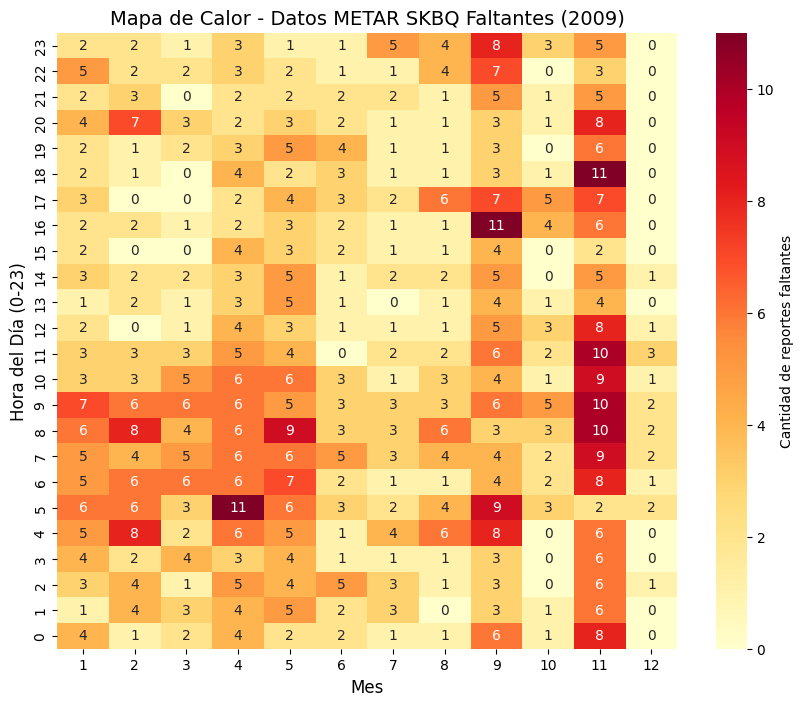

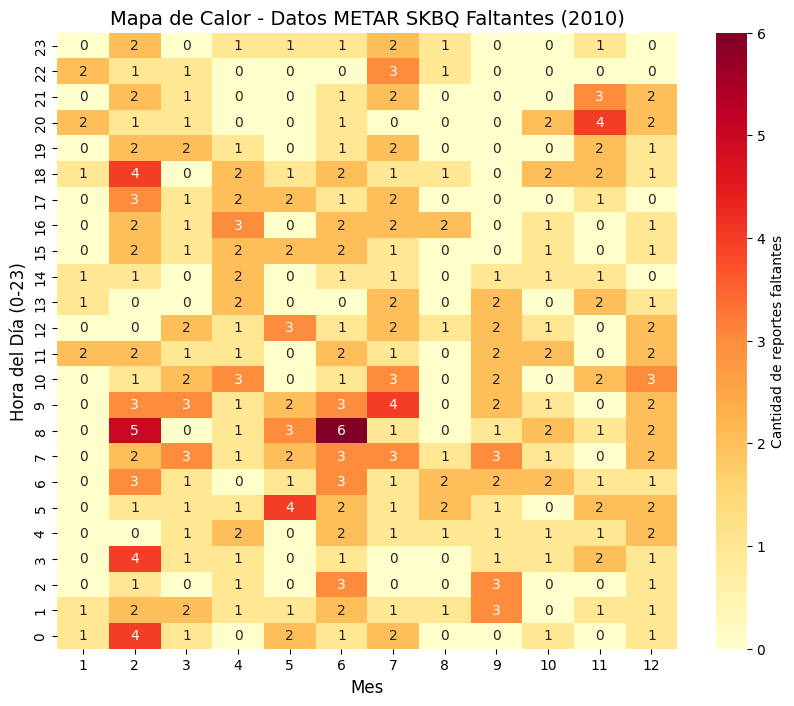

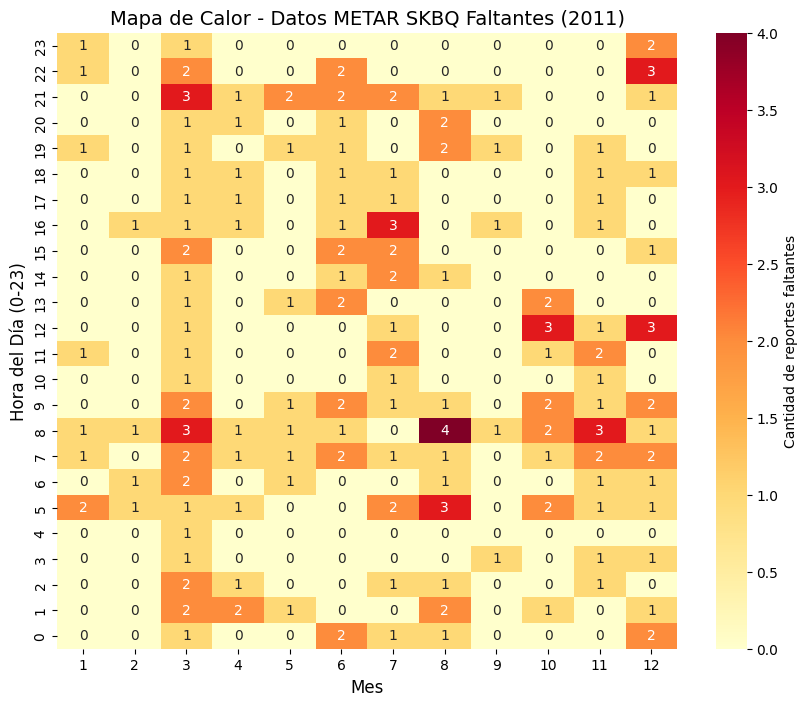

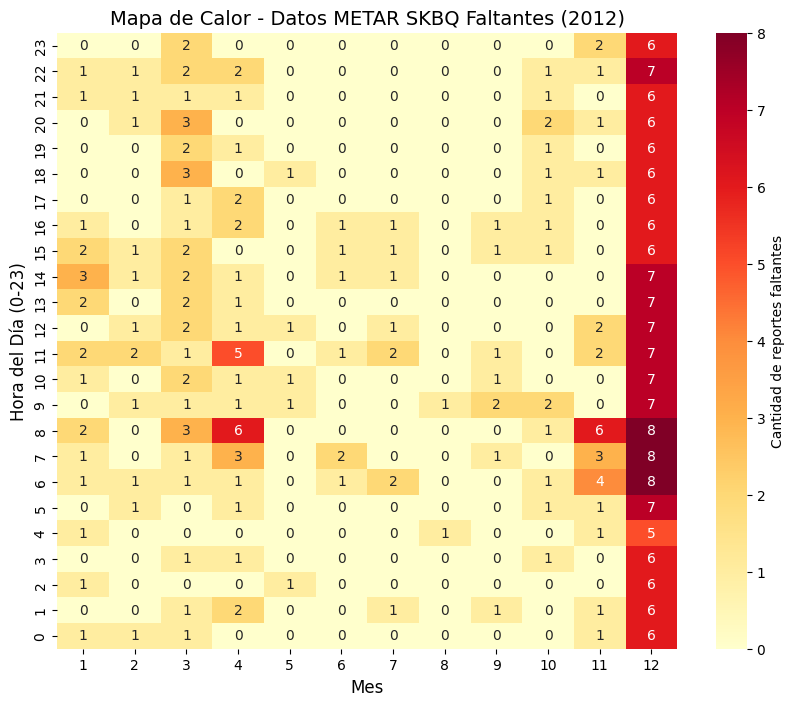

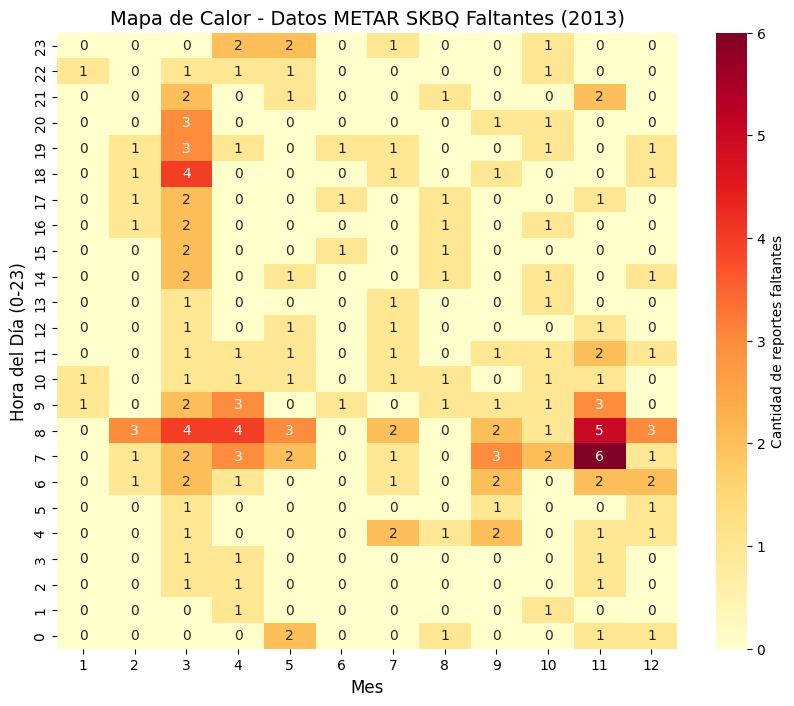

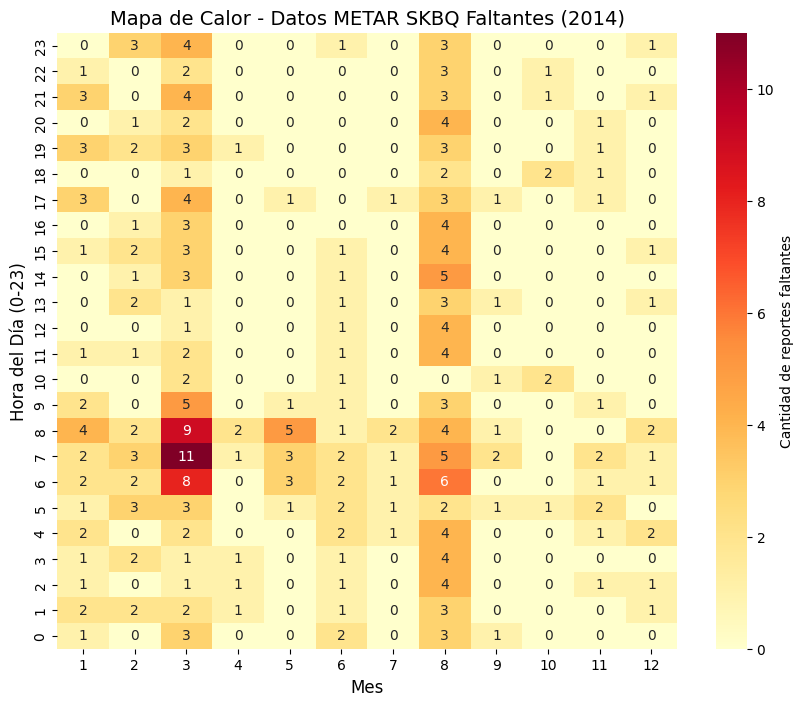

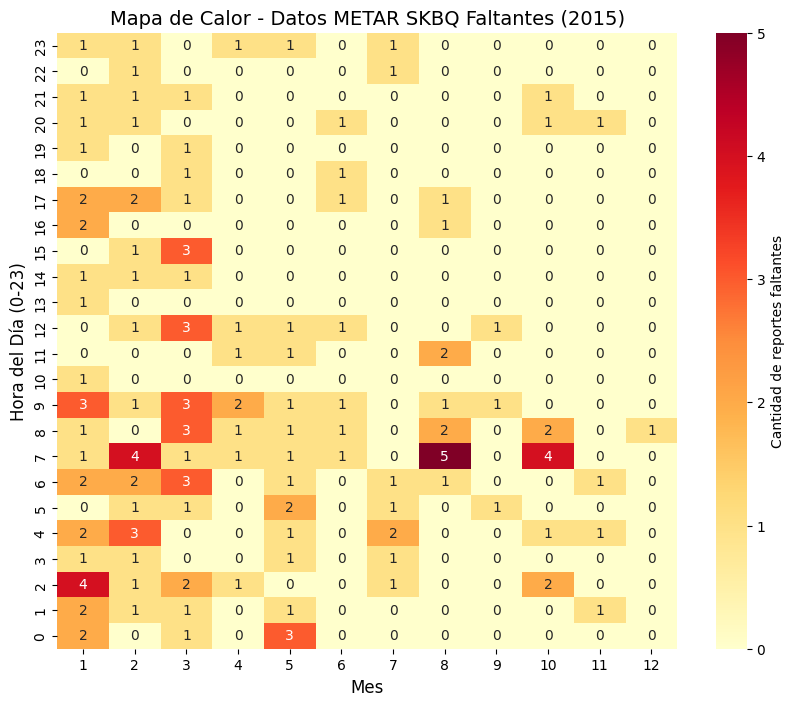

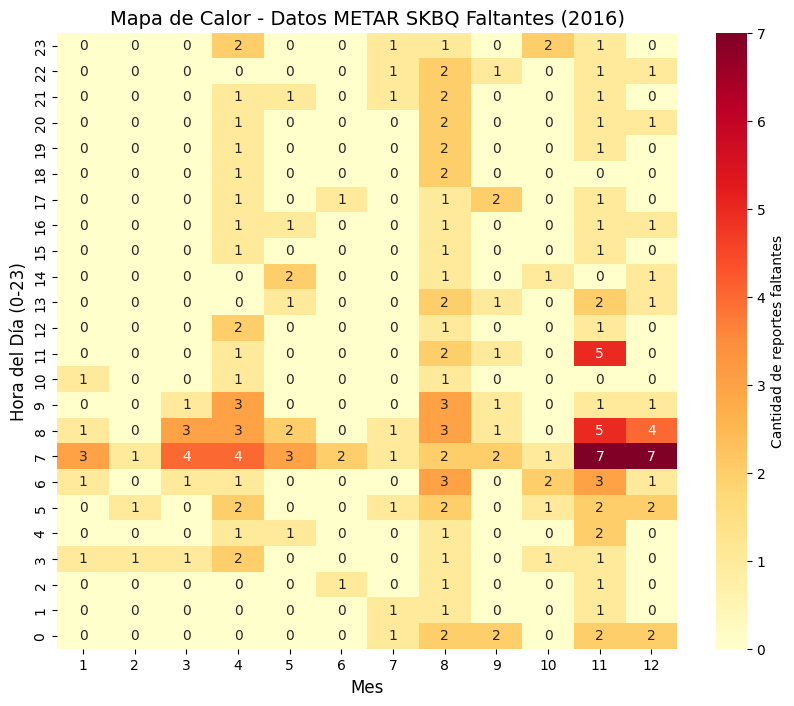

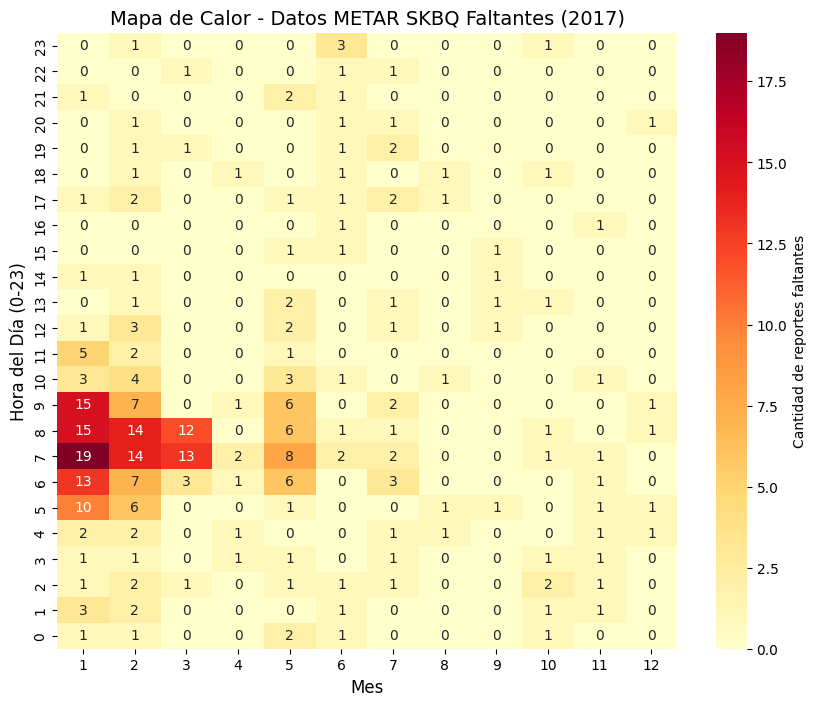

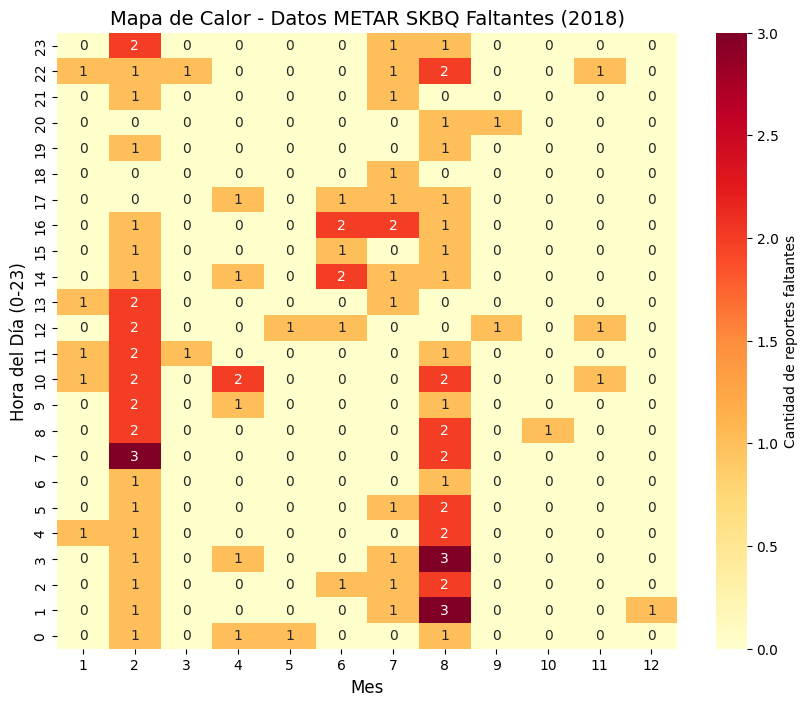

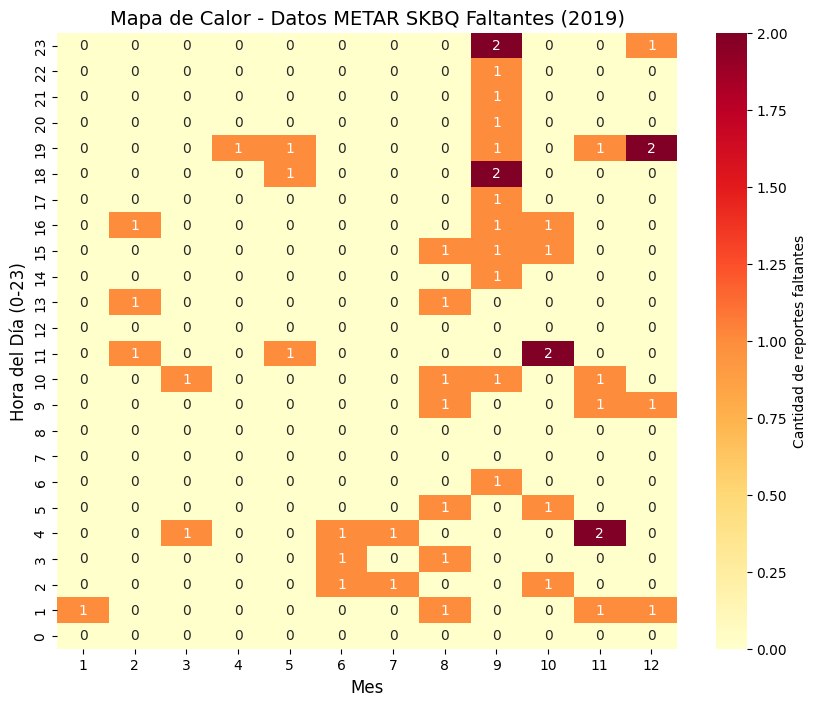

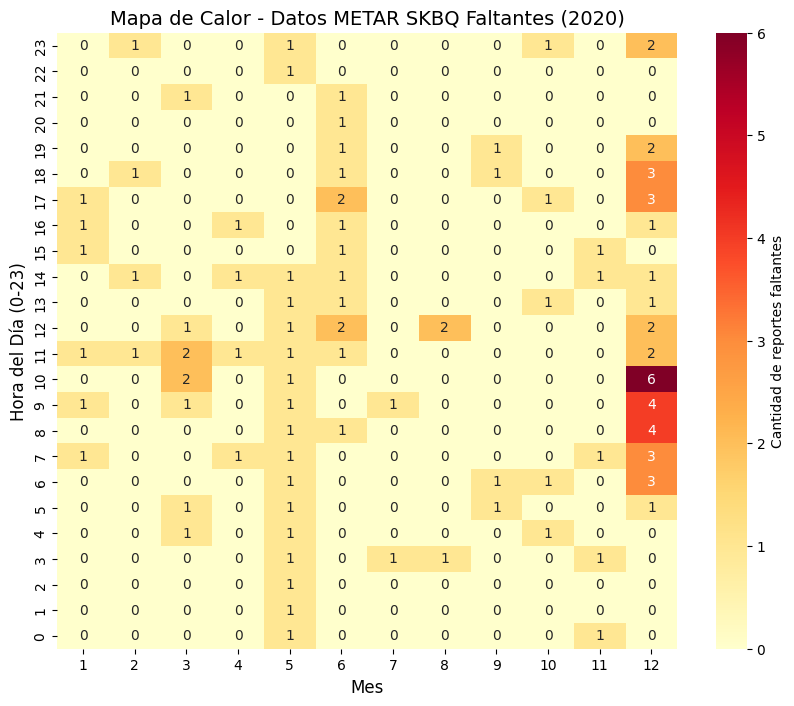

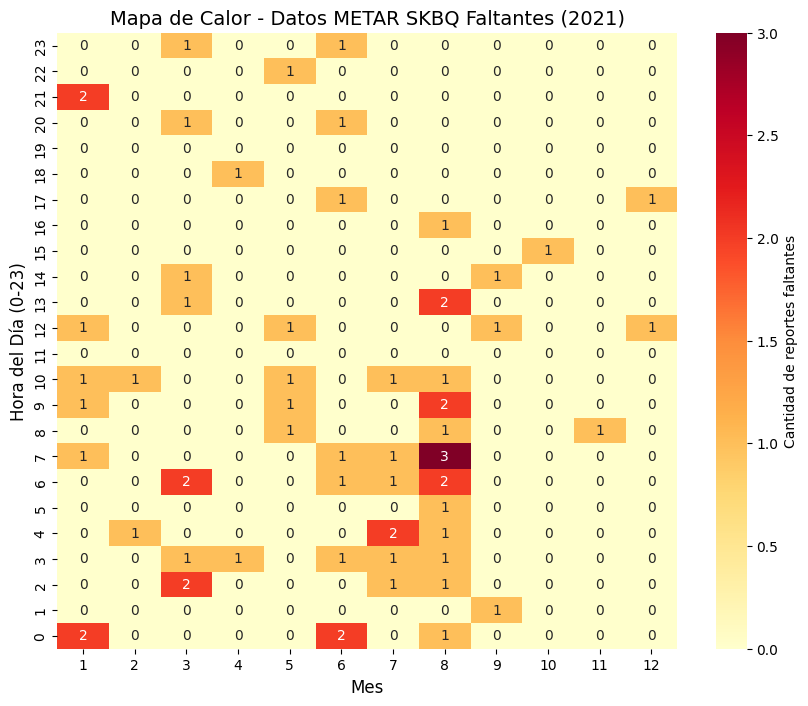

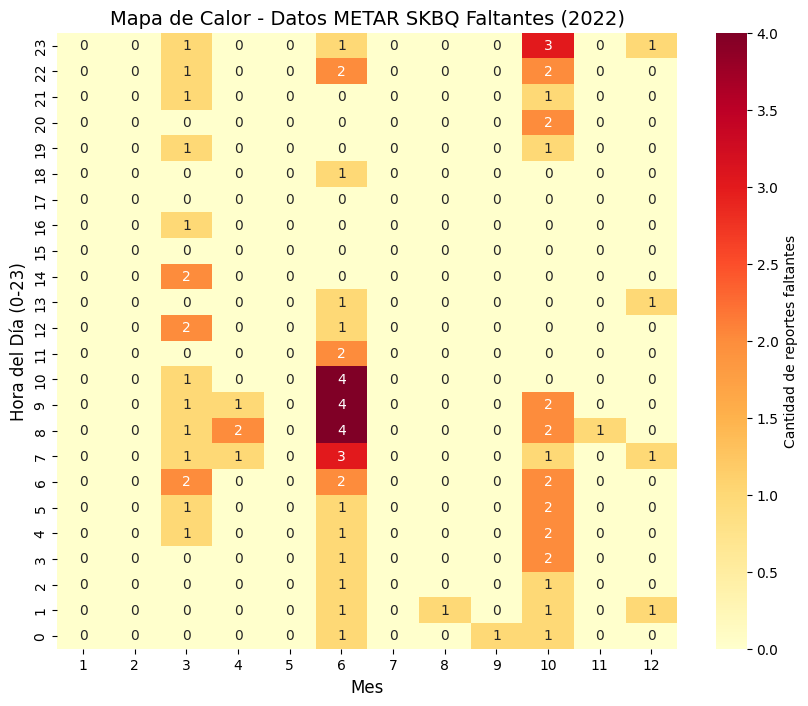

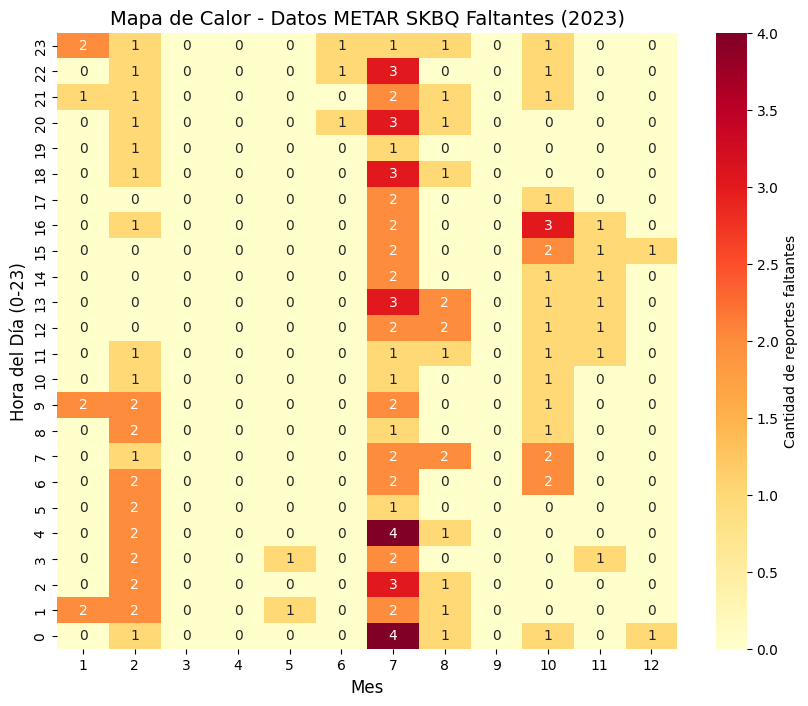

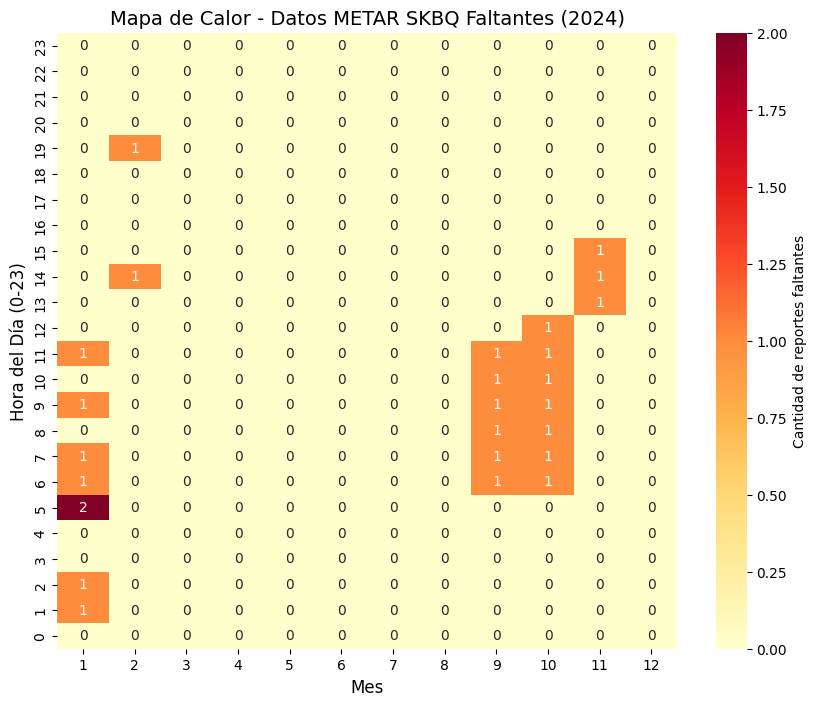

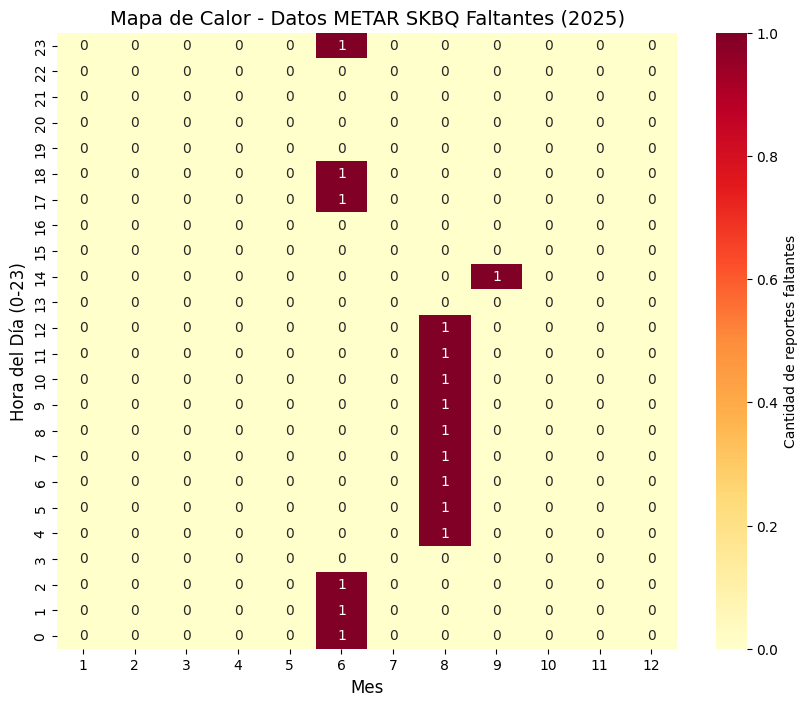

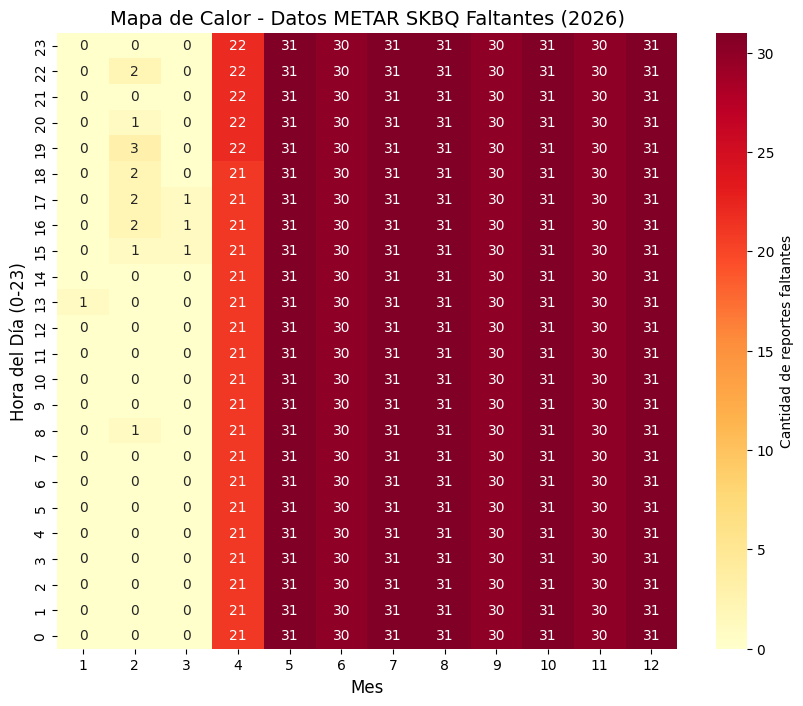

In [ ]:
# =========================================================
# FASE 2: ALINEACIÓN Y DIAGNÓSTICO (HEATMAPS DE FALTANTES)
# =========================================================

# 1. Crear el índice perfecto y continuo para ventana de tiempo
rango_completo = pd.date_range(start='2006-01-01', end='2026-12-31 23:00:00', freq='H')

# 2. Reindexar: Aquí es donde se exponen matemáticamente los "huecos"
df_diagnostico = df_pre_copy.reindex(rango_completo)

# 3. Extraer metadatos temporales para los gráficos
df_faltantes = df_diagnostico['u'].isna().to_frame(name='es_faltante')
df_faltantes['Año'] = df_faltantes.index.year
df_faltantes['Mes'] = df_faltantes.index.month
df_faltantes['Hora'] = df_faltantes.index.hour

# 4. Graficar los heatmaps anuales para el aeropuerto SKBO
df_solo_faltantes = df_faltantes[df_faltantes['es_faltante'] == True]

for anio in range(2006, 2027):
    data_anio = df_solo_faltantes[df_solo_faltantes['Año'] == anio]

    if data_anio.empty:
        continue

    pivot = pd.pivot_table(data_anio, values='es_faltante', index='Hora',
                           columns='Mes', aggfunc='count', fill_value=0)
    pivot = pivot.reindex(index=range(24), columns=range(1, 13), fill_value=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt="d",
                cbar_kws={'label': 'Cantidad de reportes faltantes'})
    plt.title(f'Mapa de Calor - Datos METAR SKBQ Faltantes ({anio})', fontsize=14)
    plt.xlabel('Mes', fontsize=12)
    plt.ylabel('Hora del Día (0-23)', fontsize=12)
    plt.gca().invert_yaxis()
    plt.show()

Los mejores datos a tomar para que luego de la imputacion ,no se presente mucho sesgo es desde el 2013 (inclusive).

In [ ]:
# 1. Transformación Vectorial (u, v) - HACER ANTES DEL RESAMPLE
# u = componente Este-Oeste, v = componente Norte-Sur

radianes = df_pre_copy['direccion'] * (np.pi / 180)
df_pre_copy['u'] = -df_pre_copy['intensidad_kt'] * np.sin(radianes)
df_pre_copy['v'] = -df_pre_copy['intensidad_kt'] * np.cos(radianes)

# 2. Definir reglas de agregación para tus columnas
reglas = {
    'u': 'mean',          # Promedio de la componente zonal
    'v': 'mean',          # Promedio de la componente meridional
    'intensidad_kt': 'mean',
    'rafaga_kt': 'max'    # Capturamos la ráfaga más fuerte de la hora
}

# 3. Forzar la frecuencia horaria (Resample)
df_modelo = df_pre_copy.resample('1H').agg(reglas)

# 4. Mantener la continuidad para el modelo (Interpolación)
# El LSTM requiere que no existan huecos en la secuencia
df_modelo['u'] = df_modelo['u'].interpolate(method='linear')
df_modelo['v'] = df_modelo['v'].interpolate(method='linear')
df_modelo['intensidad_kt'] = df_modelo['intensidad_kt'].interpolate(method='linear')
df_modelo['rafaga_kt'] = df_modelo['rafaga_kt'].fillna(0) # Si no hay reporte, rafaga es 0

/tmp/ipykernel_13746/4165241097.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_modelo = df_pre_copy.resample('1H').agg(reglas)


In [ ]:
# Muestra la sumatoria de valores NaN en cada columna
print("Cantidad de valores faltantes por columna:")
print(df_modelo.isnull().sum())

# Verifica si la frecuencia horaria es estrictamente regular
print("\n¿Es el índice estrictamente regular (1H)?:", pd.infer_freq(df_modelo.index) == 'H')

Cantidad de valores faltantes por columna:
u                0
v                0
intensidad_kt    0
rafaga_kt        0
dtype: int64

¿Es el índice estrictamente regular (1H)?: False


In [ ]:
# 1. Asignar la frecuencia horaria de forma estricta
df_modelo = df_modelo.asfreq('H')

# 2. Verificar que la etiqueta 'freq' se haya asignado correctamente
print("Frecuencia oficial del índice:", df_modelo.index.freq)

Frecuencia oficial del índice: <Hour>


/tmp/ipykernel_13746/567216096.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_modelo = df_modelo.asfreq('H')


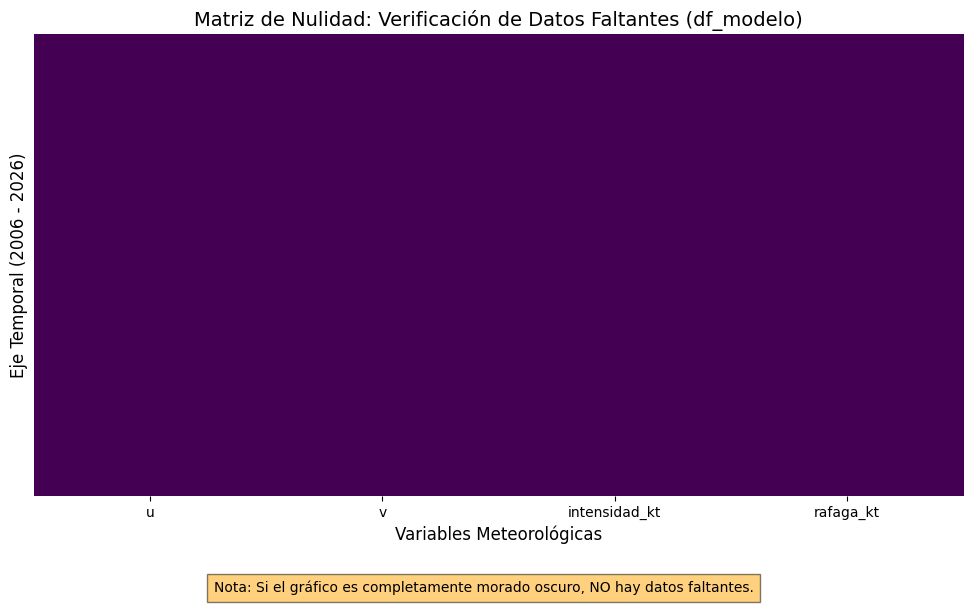

In [ ]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Crear un heatmap directamente sobre los valores booleanos de df.isnull()
# cbar=False quita la barra lateral, yticklabels=False oculta las miles de fechas del eje Y
sns.heatmap(df_modelo.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Matriz de Nulidad: Verificación de Datos Faltantes (df_modelo)', fontsize=14)
plt.xlabel('Variables Meteorológicas', fontsize=12)
plt.ylabel('Eje Temporal (2006 - 2026)', fontsize=12)

# Añadir un texto explicativo dentro del gráfico
plt.figtext(0.5, -0.05, "Nota: Si el gráfico es completamente morado oscuro, NO hay datos faltantes.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.5, "pad":5})

plt.show()

In [ ]:
# Filtrar desde 2013
df_var = df_modelo.loc['2013-01-01':].reset_index()
df_var = df_modelo.loc['2013-01-01':, ['u', 'v', 'intensidad_kt', 'rafaga_kt']].reset_index()

In [ ]:
# "/content/drive/MyDrive/MAESTRIA/
ruta_exportacion = '/content/drive/MyDrive/MAESTRIA/DATOS_ENTRENAMIENTO.csv'

# Verificar que el directorio existe (crearlo si no existe)
import os
directorio = os.path.dirname(ruta_exportacion)
if not os.path.exists(directorio):
    os.makedirs(directorio, exist_ok=True)
    print(f" Directorio creado: {directorio}")

# Exportar a CSV
df_var.to_csv(ruta_exportacion, index=False)

In [ ]:
df_var

,FECHA_REPORTE,u,v,intensidad_kt,rafaga_kt
0,2013-01-01 00:00:00,-5.209445e-01,-2.954423,3.0,0.0
1,2013-01-01 01:00:00,-2.500000e+00,-4.330127,5.0,0.0
2,2013-01-01 02:00:00,-2.819078e+00,-1.026060,3.0,0.0
3,2013-01-01 03:00:00,-1.500000e+00,-2.598076,3.0,0.0
4,2013-01-01 04:00:00,-2.000000e+00,-3.464102,4.0,0.0
...,...,...,...,...,...
116318,2026-04-09 14:00:00,-4.788282e+00,13.155697,14.0,25.0
116319,2026-04-09 15:00:00,-8.500000e+00,14.722432,17.0,0.0
116320,2026-04-09 16:00:00,-1.836970e-15,15.000000,15.0,0.0
116321,2026-04-09 17:00:00,-5.500000e+00,9.526279,11.0,0.0


# PRUEBA DE MODELOS

In [ ]:
# EXTRACION DE DATA LISTA PARA LOS MODELOS
df_var_drive = pd.read_csv('/content/drive/MyDrive/MAESTRIA/DATOS_ENTRENAMIENTO.csv')

In [ ]:
df_var = df_var_drive.copy()

In [ ]:
df_var.head()

,FECHA_REPORTE,u,v,intensidad_kt,rafaga_kt
0,2013-01-01 00:00:00,-0.520945,-2.954423,3.0,0.0
1,2013-01-01 01:00:00,-2.500000,-4.330127,5.0,0.0
2,2013-01-01 02:00:00,-2.819078,-1.026060,3.0,0.0
3,2013-01-01 03:00:00,-1.500000,-2.598076,3.0,0.0
4,2013-01-01 04:00:00,-2.000000,-3.464102,4.0,0.0


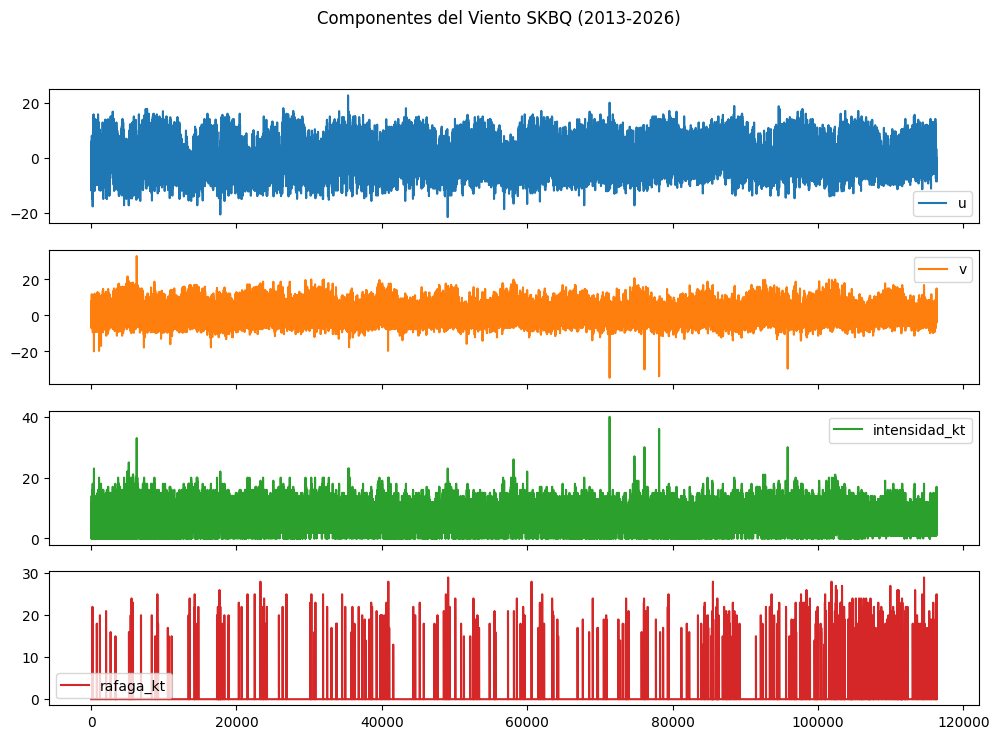

In [ ]:
# Visualización de las series temporales
df_var.plot(subplots=True, figsize=(12, 8), title="Componentes del Viento SKBQ (2013-2026)")
plt.show()

##### VAR

In [ ]:
def revisar_estacionariedad(df):
    for col in df.columns.drop("FECHA_REPORTE"):
        res = adfuller(df[col])
        print(f"Variable: {col} | p-value: {res[1]:.10f}")

revisar_estacionariedad(df_var)

Variable: u | p-value: 0.0000000000
Variable: v | p-value: 0.0000000000
Variable: intensidad_kt | p-value: 0.0000000000
Variable: rafaga_kt | p-value: 0.0000000000
